Training Logistic Regression...
Training Random Forest...
Training Support Vector Machine...
Training K-Nearest Neighbors...
Training Decision Tree...
Training Naive Bayes...

Report: Performance of Supervised Learning Algorithms
                Algorithm  Accuracy  Precision  Recall  F1-Score
0     Logistic Regression    1.0000     1.0000  1.0000    1.0000
1           Random Forest    1.0000     1.0000  1.0000    1.0000
2  Support Vector Machine    1.0000     1.0000  1.0000    1.0000
3     K-Nearest Neighbors    1.0000     1.0000  1.0000    1.0000
4           Decision Tree    1.0000     1.0000  1.0000    1.0000
5             Naive Bayes    0.9778     0.9794  0.9778    0.9777


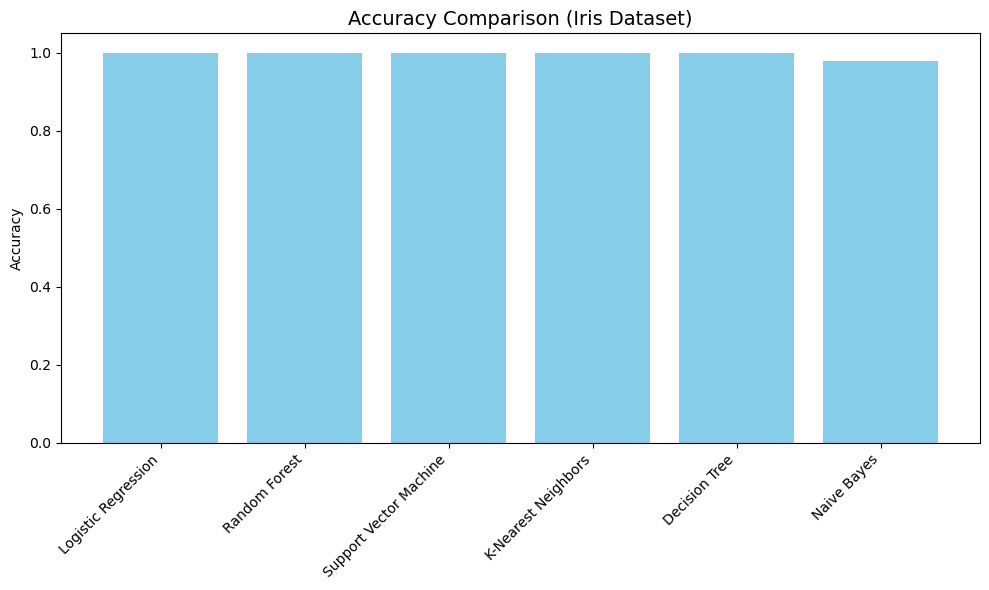

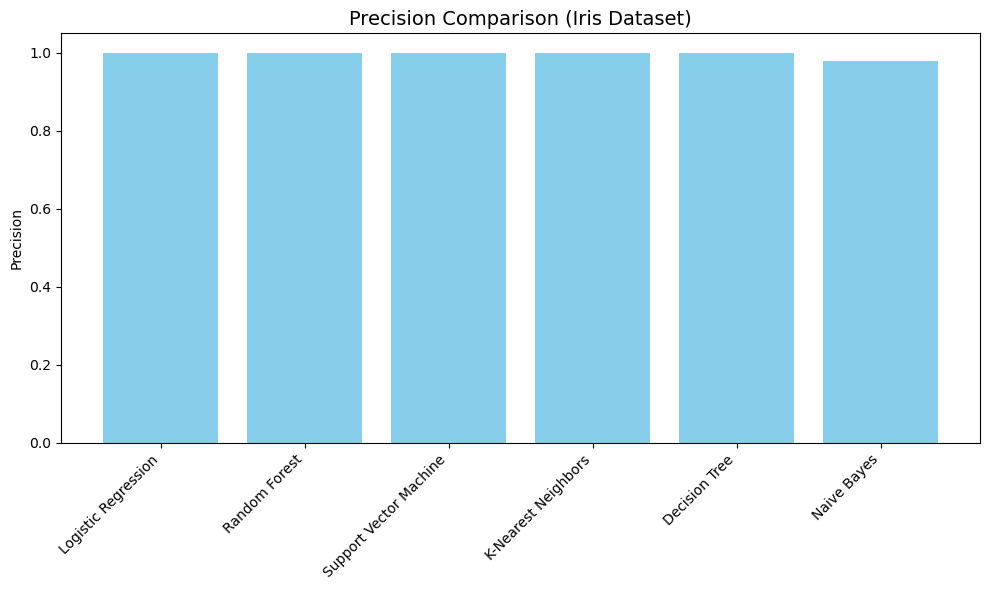

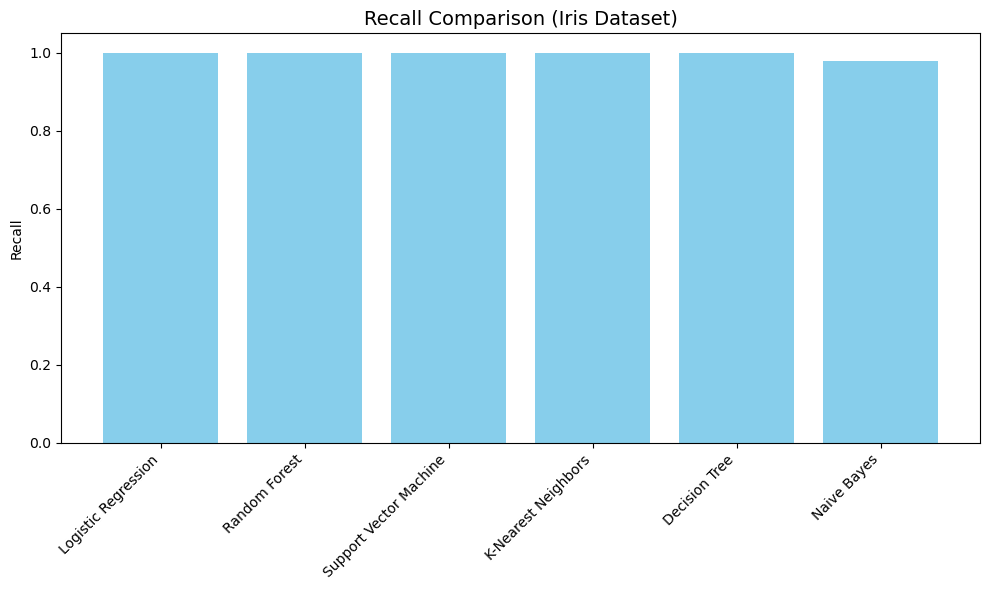

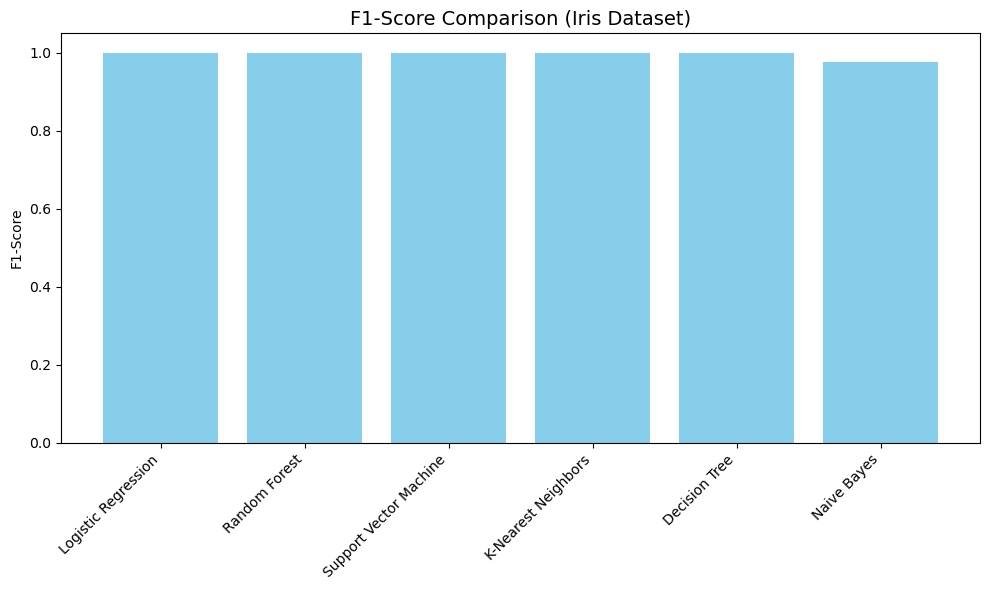

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Function to load dataset
def load_data(dataset_name="iris"):
    if dataset_name == "iris":
        data = load_iris()
    elif dataset_name == "wine":
        data = load_wine()
    else:
        raise ValueError("Unsupported dataset! Choose 'iris' or 'wine'.")
    
    X, y = data.data, data.target
    return X, y, data.feature_names, data.target_names

# Load dataset automatically
dataset_name = "iris"  # Change to "wine" for the wine dataset
X, y, feature_names, target_names = load_data(dataset_name)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define classifiers to compare
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='linear', random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB()
}

# Dictionary to store results
results = []

# Evaluate each classifier
for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Compute evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Append results
    results.append({
        'Algorithm': name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Print the report
print("\nReport: Performance of Supervised Learning Algorithms")
print(results_df)

# Export report to a CSV file
results_df.to_csv(f"{dataset_name}_comparison_report.csv", index=False)

# Visualize the results
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for metric in metrics_to_plot:
    plt.figure(figsize=(10, 6))
    plt.bar(results_df['Algorithm'], results_df[metric], color='pink')
    plt.title(f'{metric} Comparison ({dataset_name.capitalize()} Dataset)', fontsize=14)
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f"{metric}_comparison_{dataset_name}.png")  # Save plots as images
    plt.show()
